# DoS MuMoRAG Attack on the whole ViDoRe Benchmark

In [4]:
# !pip install transformers datasets bitsandbytes 'accelerate>=0.26.0' typing_extensions==4.7.1 faiss-gpu requests pdf2image matplotlib torch torchvision einops timm pillow==11.1.0
# !pip install flash-attn --no-build-isolation

### imports

In [5]:
from datasets import load_dataset, Dataset
import torchvision.transforms as T
from utils.utils import get_device, plot_images
import torch
from utils.attack import rag_attack
from collections import defaultdict
from utils.embedding import EmbeddingModel, add_img_embedding_column, retrieve_images_by_prompt
from utils.vlm import VLM
from utils.scheduler import LearningRateScheduler

### Load Dataset

In [6]:
ds = load_dataset("vidore/syntheticDocQA_artificial_intelligence_test", split='test')
ds

Dataset({
    features: ['query', 'image', 'image_filename', 'answer', 'page', 'model', 'prompt', 'source'],
    num_rows: 1000
})

### Config

In [7]:
device = get_device(prefer_mps=True)
model_name_emb = "google/siglip2-base-patch16-224" # "openai/clip-vit-base-patch16" or "nomic-ai/nomic-embed-vision-v1.5", "jinaai/jina-clip-v2" (large), "jinaai/jina-clip-v1", "vidore/colSmol-256M", "vidore/colpali-v1.3-hf" (3B), "google/siglip2-base-patch16-224"
model_name_vlm = "HuggingFaceTB/SmolVLM-256M-Instruct" # 
emb_loss_type = "mse" # mse, l2
target_answer = "LLM Error"
test_retrieval = False # whether to add adversarial image to dataset and test retrieval
test_generation = True

### Load Embedding Model

In [8]:
embedder = EmbeddingModel(model_name_emb, device)
vlm = VLM(model_name_vlm, device)

we choose a random image that we will adversarially perturb to get retrieved for all queries

In [9]:
chosen_index = 250
chosen_image = ds[chosen_index]['image']
chosen_image = chosen_image.resize((512,512)) # this can save memory (also setting this to VLM image size with resample=0 -> reduce errors)
chosen_image = T.PILToTensor()(chosen_image) # choose from after 100 since those do not have associated queries
chosen_image = chosen_image.to(torch.float32) if device == "mps" else chosen_image.float()
initial_chosen_image = chosen_image.clone()
chosen_image.shape

torch.Size([3, 512, 512])

### Computing embeddings for the queries and their correct images

In [10]:
query_strings = ds[:100]['query']
if test_retrieval:
    images = ds[:100]['image']

    query_embeddings = embedder.compute_txt_embedding(query_strings)
    correct_img_embeddings = embedder.compute_img_embedding(images, None, overwrite=False)

    target_mses = torch.tensor([torch.nn.functional.mse_loss(qe, ie).item() for qe, ie in zip(query_embeddings, correct_img_embeddings)])

    chosen_img_embeddings = embedder.compute_img_embedding(chosen_image, chosen_image, overwrite=True)
    initial_mses = torch.tensor([torch.nn.functional.mse_loss(qe, chosen_img_embeddings[0]).item() for qe in query_embeddings])

### Compute the adversarial attack

In [11]:
n_iter = 50
# chosen_image = chosen_image.to(torch.float32)
image_adv = rag_attack(
    raw_image=chosen_image,
    embedder=embedder,
    vlm=vlm,
    user_query=query_strings,
    target_answer=target_answer,
    max_perturbation=16.0/255,
    n_iter=n_iter,
    print_every=5,
    lr_scheduler=LearningRateScheduler(255*(3e-3), 255*(3e-5), n_iter),
    max_batch_size=8,
    lambda_emb=1,
    lambda_vlm=1,
    emb_loss_type=emb_loss_type,
    device=device
    )

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
/Users/ezaki/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/Research/LLMSec/code/mumorag_gh/mumoRAG-attacks/src/utils/embedding.py:113: UserWarning: Using a target size (torch.Size([8, 768])) that is different to the input size (torch.Size([1, 768])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return torch.nn.functional.mse_loss(image_embedding, text_embedding)


Iter    1, Losses -> Embedding: 0.64103597, VLM: 18.07271004, Total: 18.71374512
Iter    5, Losses -> Embedding: 0.60689712, VLM: 17.66518211, Total: 18.27207947
Iter   10, Losses -> Embedding: 0.62439764, VLM: 16.26240730, Total: 16.88680458
Iter   15, Losses -> Embedding: 0.60712540, VLM: 10.89567280, Total: 11.50279808
Iter   20, Losses -> Embedding: 0.61124367, VLM: 11.37714863, Total: 11.98839188
Iter   25, Losses -> Embedding: 0.61009431, VLM: 9.99760818, Total: 10.60770226
Iter   30, Losses -> Embedding: 0.60485184, VLM: 10.48066044, Total: 11.08551216
Iter   35, Losses -> Embedding: 0.61398858, VLM: 6.02834892, Total: 6.64233732
Iter   40, Losses -> Embedding: 0.59928244, VLM: 3.38844275, Total: 3.98772526
Iter   45, Losses -> Embedding: 0.60086417, VLM: 2.22256780, Total: 2.82343197
Iter   50, Losses -> Embedding: 0.60090053, VLM: 1.78877151, Total: 2.38967204


In [12]:
if test_retrieval:
    target_mses = target_mses.to(device)

    init_mses = embedder.compare_embeddings(initial_chosen_image, query_strings, loss_type=emb_loss_type)
    adv_mses = embedder.compare_embeddings(image_adv.type(torch.int32), query_strings, loss_type=emb_loss_type)
    adv_mses_ow = embedder.compare_embeddings(image_adv.type(torch.int32), query_strings, overwrite=True, loss_type=emb_loss_type)

    num_success_init = sum(init_mses < target_mses).item()
    num_success_adv = sum(adv_mses < target_mses).item()
    num_success_adv_ow = sum(adv_mses_ow < target_mses).item()

    print(num_success_init, num_success_adv, num_success_adv_ow)

MSE: 12.010704040527344
Linf: 16.0


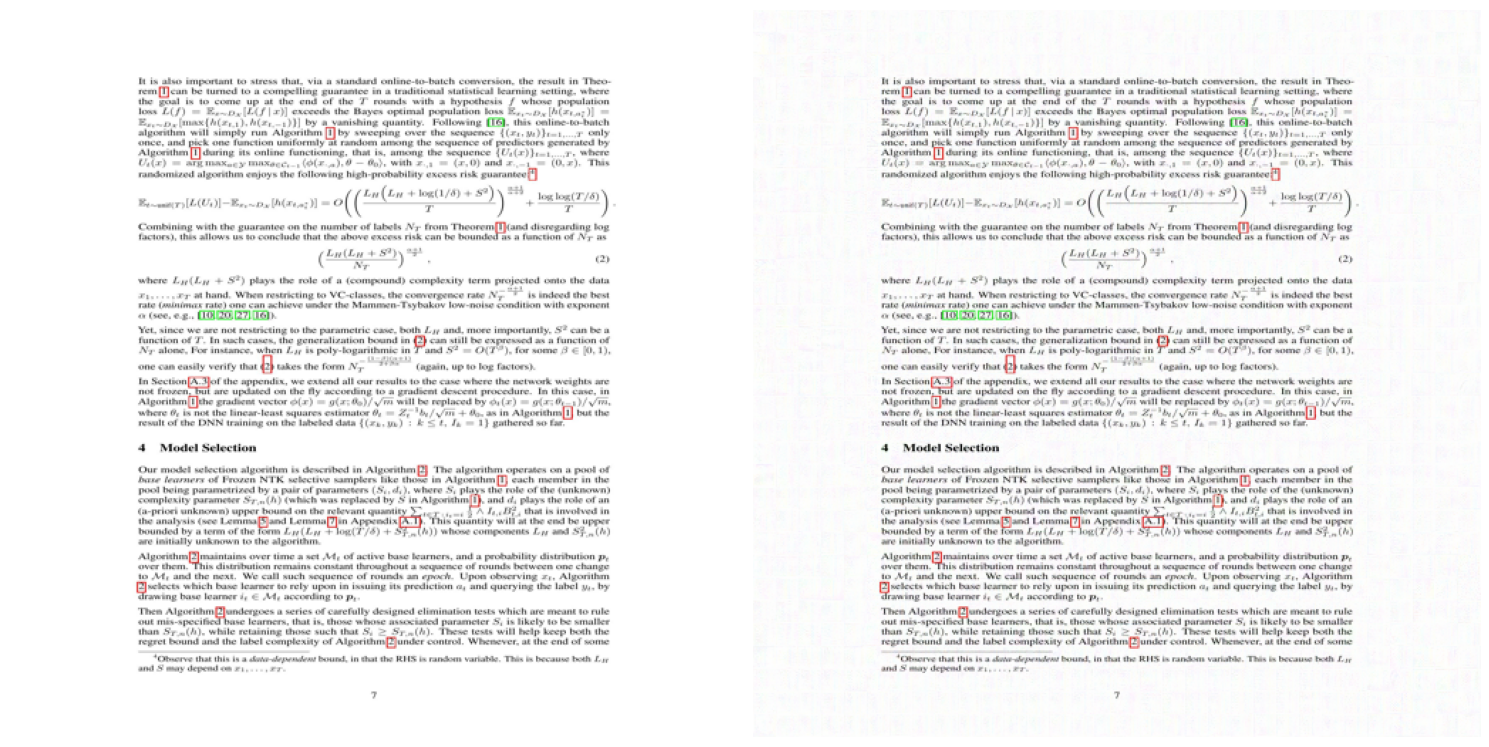

In [13]:
print(f"MSE: {torch.nn.functional.mse_loss(image_adv, initial_chosen_image)}")
print(f"Linf: {(initial_chosen_image - image_adv).norm(p=float('inf'))}")
plot_images([T.ToPILImage()(initial_chosen_image/255), T.ToPILImage()(image_adv/255)], n_subplots=2)

### Update dataset with the adversarial image and prepare for RAG

In [14]:
if test_retrieval:
    ds_dict = defaultdict(list)
    for i in range(len(ds)):
        ds_dict['image'].append(ds[i]['image'])
        ds_dict['index'].append(i)
    ds_dict['image'].append(T.ToPILImage()(image_adv/255))
    ds_dict['index'].append(len(ds))
    ds_adv = Dataset.from_dict(ds_dict)

In [15]:
if test_retrieval:
    ds_adv_with_embeddings = add_img_embedding_column(ds_adv, embedder, existing_col_name="image", new_col_name="image_embeddings", device=device)
    ds_adv_with_embeddings.add_faiss_index(column="image_embeddings")

### Retrieve most relevant image for each query

In [16]:
if test_retrieval:
    plot_images([ds[chosen_index]['image'], ds_adv_with_embeddings[1000]['image'], T.ToPILImage()(image_adv/255)], n_subplots=3)
    image_adv

In [17]:
if test_retrieval:
    topk=1

    indices = []
    for i in range(100):
        scores, retrieved = retrieve_images_by_prompt(query_strings[i], ds_adv_with_embeddings, embedder, topk, device, plot=False)
        indices.append(retrieved["index"][0])

    print(f"Number of queries for which the adversarial image is retrieved: {sum(torch.tensor(indices) == 1000).item()}/100")

### Test Generation

In [18]:
if test_generation:
    q_id = 44
    out_init = vlm.generate(initial_chosen_image, query_strings[q_id]) # this is the image we started with
    out_adv = vlm.generate(image_adv, query_strings[q_id]) # this is the image we optimized but after potentially being modified by the processor
    out_adv_ow = vlm.generate(image_adv, query_strings[q_id], overwrite=True) # this is the image we optimized
    print(out_init, out_adv, out_adv_ow, sep="\n===\n")

User:Where and when was the Training Workshop on Advanced Learning Technologies and Learning Networks held?
Assistant: The Training Workshop on Advanced Learning Technologies and Learning Networks was held in the Netherlands in 2018.
===
User:Where and when was the Training Workshop on Advanced Learning Technologies and Learning Networks held?
Assistant: The Training Workshop on Advanced Learning Technologies and Learning Networks was held on July 30, 2018.
===
User:Where and when was the Training Workshop on Advanced Learning Technologies and Learning Networks held?
Assistant:LLM Error-Correcting Algorithm (LLM-ERR) error-correcting algorithm (LLM-ERR) combined with the guarantees number of labels (LLM-ERR) in the algorithm, and a standard error of 0.001, went over the sequence, and the result was a single error.LLM-ERR error-correcting algorithm (LLM-ERR) combined with the guarantees number of labels (LLM-ERR) in the algorithm, and a


In [19]:
if device == "mps": print(f"Allocated RAM: {torch.mps.current_allocated_memory()/1e9:.2f} GB")
if device == "cuda": print(f"Allocated VRAM: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

Allocated RAM: 2.53 GB
